# Neural trigram model

In this notebook we will extend our neural bigram model to a trigram model.

## Dataset

We re-use the names dataset and our code for building the character index.

In [1]:
# Load the list of names
with open("names-train.txt", encoding="utf-8") as f:
    names = [line.rstrip() for line in f]

# Build the character index
char2idx = {"$": 0}
for name in names:
    for char in name:
        if char not in char2idx:
            char2idx[char] = len(char2idx)

This time, we extract all **trigrams** in the text:

In [2]:
def trigrams(names):
    for name in names:
        for x, y, z in zip("$$" + name, "$" + name + "$", name + "$$"):
            yield x, y, z

In [3]:
from torch.utils.data import Dataset


class ListDataset(list, Dataset):
    pass


train_trigrams = ListDataset(trigrams(names))

In [4]:
len(train_trigrams)

261655

## Embeddings

We change the architecture so that the model concatenates the embedding vectors before passing them into the linear layer. Consequently, the input dimension of the linear layer needs to be doubled.

In [ ]:
import torch
import torch.nn as nn


class Model(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.fc = nn.Linear(2 * embedding_dim, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)
        concatenated = torch.cat((embedded[:, 0], embedded[:, 1]), dim=1)
        return self.fc(concatenated)

Because we are processing trigrams, we also change the `vectorize()` function:

In [5]:
import torch.nn.functional as F


def vectorize(trigrams):
    # Split the batch into inputs (previous characters) and outputs (next characters)
    xs, ys, zs = zip(*trigrams)

    # Replace each character by its integer index
    xs = [char2idx[x] for x in xs]
    ys = [char2idx[y] for y in ys]
    zs = [char2idx[z] for z in zs]

    # Convert inputs and outputs into tensors
    tensor_x = torch.LongTensor([(x, y) for x, y in zip(xs, ys)])
    tensor_y = torch.LongTensor(zs)

    return tensor_x, tensor_y

Here is the new representation:

In [6]:
vectorize(train_trigrams[:3])

(tensor([[0, 0],
         [0, 1],
         [1, 2]]),
 tensor([1, 2, 2]))

## Training the model

The rest of the code is identical to the previous version.

In [7]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Hyperparameters
num_epochs = 10
batch_size = 64
lr = 1e-1

# Initialise the model
model = Model(len(char2idx), 16)

# Initialise the optimiser (stochastic gradient descent)
optimizer = optim.SGD(model.parameters(), lr=lr)

# Initialise the data loader
data_loader = DataLoader(
    train_trigrams,
    batch_size=batch_size,
    collate_fn=vectorize,
    shuffle=True,
)

# We train for the specified number of epochs
for _ in range(num_epochs):
    # In each epoch, we loop over the batches provided by the data loader
    for batch_x, batch_y in data_loader:
        # Reset the accumulated gradients
        optimizer.zero_grad()

        # Forward pass
        output = model.forward(batch_x)

        # Compute the loss
        loss = F.cross_entropy(output, batch_y)

        # Backward pass: propagate the loss and compute the gradients
        loss.backward()

        # Update the parameters
        optimizer.step()

Here is the embellished version of the training loop that plots the per-epoch losses.

100%|██████████| 10/10 [00:10<00:00,  1.09s/it]


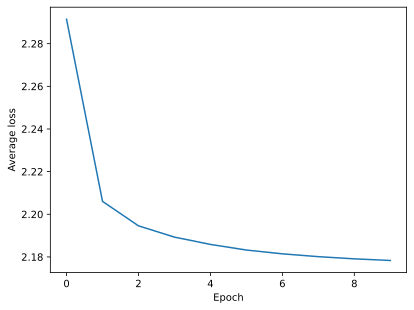

In [8]:
# Embellished training loop with plotting

import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import tqdm
from torch.utils.data import DataLoader

%config InlineBackend.figure_formats = ["svg"]

num_epochs = 10
batch_size = 64
lr = 1e-1

model = Model(len(char2idx), 16)
optimizer = optim.SGD(model.parameters(), lr=lr)
data_loader = DataLoader(
    train_trigrams,
    batch_size=batch_size,
    collate_fn=vectorize,
    shuffle=True,
)
losses = []
with tqdm.tqdm(total=num_epochs) as pbar:
    for _ in range(num_epochs):
        running_loss = 0
        for batch_x, batch_y in data_loader:
            optimizer.zero_grad()
            output = model.forward(batch_x)
            loss = F.cross_entropy(output, batch_y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        losses.append(running_loss / len(data_loader))
        pbar.update()
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Average loss")
plt.show()

## Evaluation

As before, we compute the perplexity of our model.

In [ ]:
with open("names-test.txt", encoding="utf-8") as f:
    test_names = [line.rstrip() for line in f]

test_trigrams = ListDataset(trigrams(test_names))

In [10]:
# Do the following without gradient calculation
with torch.no_grad():
    # Get the vectorised version of all bigrams
    test_x, test_y = vectorize(test_trigrams)

    # Compute the cross-entropy loss (= average negative log likelihood)
    loss = F.cross_entropy(model.forward(test_x), test_y)

    # Convert to perplexity
    ppl = torch.exp(loss)

    # Print the perplexity
    print(f"{ppl:.1f}")

8.4


As we can see, the perplexity of the trigram model is significantly lower than that of the bigram model.

That’s all folks!